# 01 — Vector Research Semis Basket StatArb

Strategy: **Cross-Sectional Equity Dispersion — Basket StatArb**

Scope:
- Research only.
- No live trading.
- No order submission.
- No IBKR connection.
- No edge validation yet.

This notebook is a first-pass vectorized research test. It is designed to answer whether the 09:30–10:00 New York residual-dispersion signal has enough research merit to justify a more realistic event-driven simulator.

## 1. Guardrails and Known Missing Inputs

This notebook intentionally does **not** import or modify production live-trading code. It only reads local historical bars and constructs vectorized research outputs.

Known missing inputs for this first version:
- information missing: point-in-time semiconductor index membership.
- information missing: corporate actions adjustment policy for the stored minute bars.
- information missing: earnings calendar, so `exclude_earnings_days` is disabled.
- information missing: borrow availability and short-sale constraints.
- information missing: spreads, quotes, and market impact data.

Because the starter universe is static, any positive result should be treated as preliminary and potentially survivorship-biased until point-in-time membership and corporate action handling are verified.

In [46]:
from __future__ import annotations

from pathlib import Path
from datetime import time
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
plt.style.use("seaborn-v0_8-whitegrid")

In [47]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the Bluegrey project root without depending on the current notebook directory."""
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "src").exists() and (candidate / "research").exists():
            return candidate
        if (candidate / "Bluegrey" / "src").exists() and (candidate / "Bluegrey" / "research").exists():
            return candidate / "Bluegrey"
    raise RuntimeError("information missing: could not locate the Bluegrey project root from this notebook cwd")

PROJECT_ROOT = find_project_root()
RESEARCH_DIR = PROJECT_ROOT / "research" / "Jordi" / "cross_sectional_equity_dispersion"
OUTPUT_DIR = RESEARCH_DIR / "outputs" / "01_vector_research_semis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey
OUTPUT_DIR: /Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey/research/Jordi/cross_sectional_equity_dispersion/outputs/01_vector_research_semis


## 2. Imports and Configuration

The primary benchmark is `SMH`. `SOXX` is loaded when available and can be used as an alternative benchmark by changing `CONFIG["benchmark"]`.

The default `max_weight_per_name = 0.05` can make full 100% gross exposure infeasible for a small micro-universe. The portfolio constructor respects the cap first and reports realized gross exposure, so low gross is a data/configuration finding rather than something hidden by over-scaling.

In [56]:
CONFIG = {
    "strategy_name": "cross_sectional_equity_dispersion_basket_statarb",
    "sector_name": "semiconductors",
    "benchmark": "SMH",
    "alternative_benchmark": "SOXX",
    "bar_size": "1min",
    "timezone": "America/New_York",
    "session_open": "09:30",
    "session_close": "16:00",
    "signal_time": "10:00",
    "entry_start": "10:00",
    "entry_end": "10:02",
    "exit_start": "15:53",
    "exit_end": "15:55",
    "long_quantile": 0.20,
    "short_quantile": 0.20,
    "min_names_per_day": 10,
    "min_beta_obs": 10,
    "max_weight_per_name": 0.05,
    "gross_exposure": 1.0,
    "target_net_exposure": 0.0,
    "target_beta_exposure": 0.0,
    "cost_bps_per_side_grid": [1, 2, 5, 10],
    "beta_lookback_days": 20,
    "use_etf_hedge": False,
    "exclude_earnings_days": False,
    "arctic_library": "equity_min",
    "assume_naive_timestamps_are_utc": True,
    "save_outputs": False,
}

STOCK_TICKERS = [
    "ACLS", "ADI", "AEIS", "AMAT", "AMD", "AVGO", "COHR", "CRUS", "FORM",
    "INTC", "KLAC", "LRCX", "LSCC", "MCHP", "MPWR", "MRVL", "MU", "NVDA",
    "NXPI", "ON", "QCOM", "QRVO", "STX",
]

EXCLUDE_ZERO_BAR_TICKERS = ["SWKS", "TER", "TXN", "WDC"]
ETF_TICKERS = [CONFIG["benchmark"], CONFIG["alternative_benchmark"]]
REQUESTED_TICKERS = sorted(set(STOCK_TICKERS + ETF_TICKERS + EXCLUDE_ZERO_BAR_TICKERS))

assert CONFIG["benchmark"] in ETF_TICKERS
assert CONFIG["use_etf_hedge"] is False
assert CONFIG["exclude_earnings_days"] is False

CONFIG

{'strategy_name': 'cross_sectional_equity_dispersion_basket_statarb',
 'sector_name': 'semiconductors',
 'benchmark': 'SMH',
 'alternative_benchmark': 'SOXX',
 'bar_size': '1min',
 'timezone': 'America/New_York',
 'session_open': '09:30',
 'session_close': '16:00',
 'signal_time': '10:00',
 'entry_start': '10:00',
 'entry_end': '10:02',
 'exit_start': '15:53',
 'exit_end': '15:55',
 'long_quantile': 0.2,
 'short_quantile': 0.2,
 'min_names_per_day': 10,
 'min_beta_obs': 10,
 'max_weight_per_name': 0.05,
 'gross_exposure': 1.0,
 'target_net_exposure': 0.0,
 'target_beta_exposure': 0.0,
 'cost_bps_per_side_grid': [1, 2, 5, 10],
 'beta_lookback_days': 20,
 'use_etf_hedge': False,
 'exclude_earnings_days': False,
 'arctic_library': 'equity_min',
 'assume_naive_timestamps_are_utc': True,
 'save_outputs': False}

## 3. Data Loading

The repo currently stores Polygon minute bars in ArcticDB through `tools/download_history_polygon.py`. That ingestor writes one symbol per ArcticDB symbol and notes that Polygon timestamps are stored as naive UTC timestamps in this project.

This loader tries, in order:
1. ArcticDB library `equity/min` under `src/data/arctic_db`.
2. Local one-file-per-ticker or combined CSV/Parquet files under likely research/data folders.

If neither source exists, the notebook will keep going with empty tables and explicitly print `information missing: data path`.

In [57]:
COLUMN_ALIASES = {
    "t": "timestamp", "date": "timestamp", "datetime": "timestamp", "time": "timestamp",
    "symbol": "ticker", "asset": "ticker",
    "o": "open", "h": "high", "l": "low", "c": "close", "v": "volume", "vw": "vwap",
}
REQUIRED_COLUMNS = ["timestamp", "ticker", "open", "high", "low", "close", "volume"]
PRICE_COLUMNS = ["open", "high", "low", "close"]


def normalize_ohlcv_frame(df: pd.DataFrame, ticker: str | None = None) -> pd.DataFrame:
    """Normalize raw ArcticDB/file bars to timestamp,ticker,open,high,low,close,volume."""
    if df is None or df.empty:
        return pd.DataFrame(columns=REQUIRED_COLUMNS)

    out = df.copy()
    out = out.rename(columns={c: COLUMN_ALIASES.get(str(c).lower(), c) for c in out.columns})

    if "timestamp" not in out.columns:
        if isinstance(out.index, pd.DatetimeIndex):
            out = out.reset_index().rename(columns={out.index.name or "index": "timestamp"})
        else:
            out = out.reset_index().rename(columns={"index": "timestamp"})

    if "ticker" not in out.columns:
        out["ticker"] = ticker

    for col in PRICE_COLUMNS + ["volume"]:
        if col not in out.columns:
            out[col] = np.nan
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["ticker"] = out["ticker"].astype(str).str.upper()
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out = out.dropna(subset=["timestamp", "ticker"])
    out = out[REQUIRED_COLUMNS]
    out = out.sort_values(["ticker", "timestamp"])
    out = out.drop_duplicates(["ticker", "timestamp"], keep="last")
    return out


def local_arctic_uri() -> str:
    return f"lmdb://{PROJECT_ROOT / 'src' / 'data' / 'arctic_db'}?map_size=100GB"


def load_from_arctic(tickers: list[str], library_name: str) -> tuple[pd.DataFrame, dict]:
    meta = {"source": "arcticdb", "uri": local_arctic_uri(), "library": library_name, "loaded": [], "missing": [], "error": None}
    try:
        import arcticdb as adb
    except Exception as exc:
        meta["error"] = f"information missing: arcticdb import failed: {exc}"
        return pd.DataFrame(columns=REQUIRED_COLUMNS), meta

    try:
        arctic = adb.Arctic(meta["uri"])
        libraries = set(arctic.list_libraries())
        if library_name not in libraries:
            meta["error"] = f"information missing: ArcticDB library {library_name!r} not found. Available libraries: {sorted(libraries)}"
            return pd.DataFrame(columns=REQUIRED_COLUMNS), meta

        lib = arctic[library_name]
        symbols = set(lib.list_symbols())
        frames = []
        for ticker in tickers:
            if ticker not in symbols:
                meta["missing"].append(ticker)
                continue
            raw = lib.read(ticker).data
            norm = normalize_ohlcv_frame(raw, ticker=ticker)
            if norm.empty:
                meta["missing"].append(ticker)
                continue
            frames.append(norm)
            meta["loaded"].append(ticker)

        if not frames:
            meta["error"] = "information missing: no requested tickers were found with non-empty bars in ArcticDB"
            return pd.DataFrame(columns=REQUIRED_COLUMNS), meta
        return pd.concat(frames, ignore_index=True), meta
    except Exception as exc:
        meta["error"] = f"information missing: ArcticDB load failed: {exc}"
        return pd.DataFrame(columns=REQUIRED_COLUMNS), meta


def candidate_file_roots() -> list[Path]:
    return [
        PROJECT_ROOT / "data",
        PROJECT_ROOT / "src" / "data",
        RESEARCH_DIR / "data",
        RESEARCH_DIR / "outputs",
    ]


def load_from_files(tickers: list[str]) -> tuple[pd.DataFrame, dict]:
    meta = {"source": "files", "roots": [str(p) for p in candidate_file_roots()], "loaded": [], "missing": [], "error": None}
    files = []
    for root in candidate_file_roots():
        if root.exists():
            files.extend(list(root.rglob("*.parquet")))
            files.extend(list(root.rglob("*.csv")))

    if not files:
        meta["error"] = "information missing: data path"
        return pd.DataFrame(columns=REQUIRED_COLUMNS), meta

    frames = []
    ticker_set = set(tickers)
    for file_path in files:
        try:
            raw = pd.read_parquet(file_path) if file_path.suffix.lower() == ".parquet" else pd.read_csv(file_path)
        except Exception:
            continue

        inferred_ticker = None
        for ticker in tickers:
            if file_path.stem.upper().startswith(ticker):
                inferred_ticker = ticker
                break

        norm = normalize_ohlcv_frame(raw, ticker=inferred_ticker)
        if norm.empty:
            continue
        norm = norm[norm["ticker"].isin(ticker_set)]
        if norm.empty:
            continue
        frames.append(norm)
        meta["loaded"].extend(sorted(norm["ticker"].unique()))

    if not frames:
        meta["error"] = "information missing: no supported OHLCV files matched requested tickers"
        return pd.DataFrame(columns=REQUIRED_COLUMNS), meta

    data = pd.concat(frames, ignore_index=True).drop_duplicates(["ticker", "timestamp"], keep="last")
    meta["loaded"] = sorted(set(meta["loaded"]))
    meta["missing"] = sorted(ticker_set - set(meta["loaded"]))
    return data, meta


def load_intraday_bars(tickers: list[str]) -> tuple[pd.DataFrame, dict]:
    bars, meta = load_from_arctic(tickers, CONFIG["arctic_library"])
    if not bars.empty:
        return bars, meta
    file_bars, file_meta = load_from_files(tickers)
    return file_bars, {"arctic_attempt": meta, "file_attempt": file_meta}

bars_raw, load_meta = load_intraday_bars(REQUESTED_TICKERS)
print(load_meta)
print("bars_raw shape:", bars_raw.shape)
bars_raw.head()

20260616 19:22:54.286225 412839 W arcticdb | LMDB path at /Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey/src/data/arctic_db/ has already been opened in this process which is not supported by LMDB. You should only open a single Arctic instance over a given LMDB path. To continue safely, you should delete this Arctic instance and any others over the LMDB path in this process and then try again. Current process ID=[8666]


{'source': 'arcticdb', 'uri': 'lmdb:///Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey/src/data/arctic_db?map_size=100GB', 'library': 'equity_min', 'loaded': ['ACLS', 'ADI', 'AEIS', 'AMAT', 'AMD', 'AVGO', 'COHR', 'CRUS', 'FORM', 'INTC', 'KLAC', 'LRCX', 'LSCC', 'MCHP', 'MPWR', 'MRVL', 'MU', 'NVDA', 'NXPI', 'ON', 'QCOM', 'QRVO', 'SMH', 'SOXX', 'STX', 'SWKS', 'TER', 'TXN', 'WDC'], 'missing': [], 'error': None}
bars_raw shape: (15817285, 7)


,timestamp,ticker,open,high,low,close,volume
0,2021-07-01 13:30:00,ACLS,40.60,40.60,40.50,40.50,3459.0
1,2021-07-01 13:31:00,ACLS,40.40,40.40,40.40,40.40,1012.0
2,2021-07-01 13:32:00,ACLS,40.63,40.63,40.59,40.59,450.0
3,2021-07-01 13:33:00,ACLS,40.57,40.60,40.45,40.45,1157.0
4,2021-07-01 13:35:00,ACLS,40.55,40.55,40.55,40.55,746.0


## 4. Data Quality Checks

Compute first and last timestamp, bar counts, a simple coverage proxy, trading days, missing required bars, zero-bar exclusions, bars per ticker, first/last dates, and valid names per day.

Configured zero-bar exclusions: ['SWKS', 'TER', 'TXN', 'WDC']


,ticker,first_timestamp,last_timestamp,bars,trading_days,coverage_proxy,excluded_reason
17,NVDA,2021-07-01 08:00:00,2026-06-12 23:59:00,1045475,1336,1.000000,
4,AMD,2021-07-01 08:00:00,2026-06-12 23:59:00,958962,1336,0.917250,
9,INTC,2021-07-01 08:06:00,2026-06-12 23:59:00,892317,1336,0.853504,
16,MU,2021-07-01 08:00:00,2026-06-12 23:59:00,767026,1332,0.733663,
5,AVGO,2021-07-01 12:22:00,2026-06-12 23:59:00,650244,1306,0.621960,
15,MRVL,2021-07-01 08:28:00,2026-06-12 23:59:00,637644,1332,0.609908,
20,QCOM,2021-07-01 08:20:00,2026-06-12 23:58:00,592779,1327,0.566995,
22,SMH,2021-07-01 08:10:00,2026-06-12 23:59:00,590950,1311,0.565245,
23,SOXX,2021-07-01 11:03:00,2026-06-12 23:59:00,557986,1282,0.533715,
3,AMAT,2021-07-01 09:13:00,2026-06-12 23:59:00,555123,1319,0.530977,


,ticker,excluded_reason


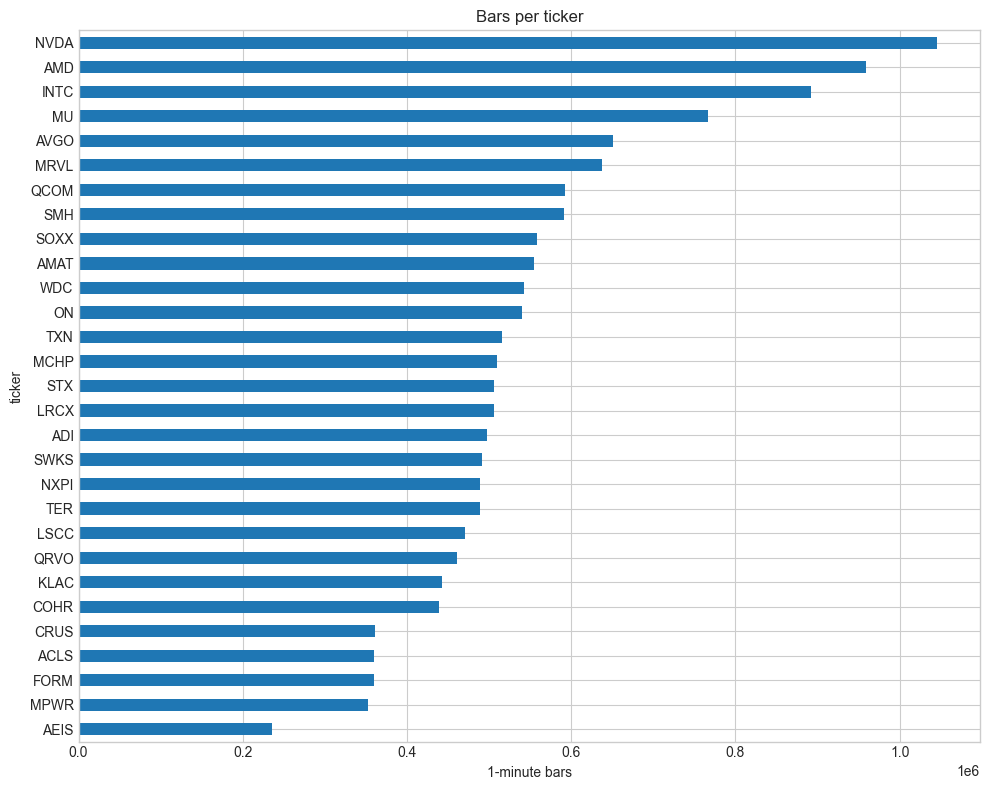

,ticker,first_timestamp,last_timestamp,bars,trading_days,coverage_proxy
17,NVDA,2021-07-01 08:00:00,2026-06-12 23:59:00,1045475,1336,1.000000
4,AMD,2021-07-01 08:00:00,2026-06-12 23:59:00,958962,1336,0.917250
9,INTC,2021-07-01 08:06:00,2026-06-12 23:59:00,892317,1336,0.853504
16,MU,2021-07-01 08:00:00,2026-06-12 23:59:00,767026,1332,0.733663
5,AVGO,2021-07-01 12:22:00,2026-06-12 23:59:00,650244,1306,0.621960
15,MRVL,2021-07-01 08:28:00,2026-06-12 23:59:00,637644,1332,0.609908
20,QCOM,2021-07-01 08:20:00,2026-06-12 23:58:00,592779,1327,0.566995
22,SMH,2021-07-01 08:10:00,2026-06-12 23:59:00,590950,1311,0.565245
23,SOXX,2021-07-01 11:03:00,2026-06-12 23:59:00,557986,1282,0.533715
3,AMAT,2021-07-01 09:13:00,2026-06-12 23:59:00,555123,1319,0.530977


In [60]:
def summarize_raw_coverage(bars: pd.DataFrame, requested: list[str]) -> pd.DataFrame:
    if bars.empty:
        return pd.DataFrame({"ticker": requested, "first_timestamp": pd.NaT, "last_timestamp": pd.NaT, "bars": 0, "trading_days": 0, "coverage_proxy": 0.0, "excluded_reason": "information missing: no bars loaded"})
    summary = bars.groupby("ticker").agg(first_timestamp=("timestamp", "min"), last_timestamp=("timestamp", "max"), bars=("timestamp", "size"), trading_days=("timestamp", lambda s: pd.Series(pd.to_datetime(s).dt.date).nunique())).reset_index()
    summary = pd.DataFrame({"ticker": requested}).merge(summary, on="ticker", how="left")
    summary["bars"] = summary["bars"].fillna(0).astype(int)
    summary["trading_days"] = summary["trading_days"].fillna(0).astype(int)
    max_bars = summary["bars"].max()
    summary["coverage_proxy"] = np.where(max_bars > 0, summary["bars"] / max_bars, 0.0)
    summary["excluded_reason"] = np.where(summary["bars"].eq(0), "zero bars", "")
    return summary.sort_values(["bars", "ticker"], ascending=[False, True])

coverage = summarize_raw_coverage(bars_raw, REQUESTED_TICKERS)
print("Configured zero-bar exclusions:", EXCLUDE_ZERO_BAR_TICKERS)
display(coverage)
display(coverage.loc[coverage["bars"].eq(0), ["ticker", "excluded_reason"]])
if not coverage.empty:
    ax = coverage.sort_values("bars").plot.barh(x="ticker", y="bars", figsize=(10, 8), legend=False, title="Bars per ticker")
    ax.set_xlabel("1-minute bars")
    plt.tight_layout(); plt.show()
display(coverage[["ticker", "first_timestamp", "last_timestamp", "bars", "trading_days", "coverage_proxy"]])

## 5. Timezone and RTH Filtering

Timestamps are converted to timezone-aware `America/New_York` before filtering to regular trading hours: `09:30 <= time <= 16:00`.

In [61]:
def parse_hhmm(value: str) -> time:
    hour, minute = map(int, value.split(":"))
    return time(hour, minute)

SESSION_OPEN = parse_hhmm(CONFIG["session_open"])
SESSION_CLOSE = parse_hhmm(CONFIG["session_close"])
SIGNAL_TIME = parse_hhmm(CONFIG["signal_time"])
ENTRY_START = parse_hhmm(CONFIG["entry_start"])
ENTRY_END = parse_hhmm(CONFIG["entry_end"])
EXIT_START = parse_hhmm(CONFIG["exit_start"])
EXIT_END = parse_hhmm(CONFIG["exit_end"])

def convert_timestamp_to_ny(ts: pd.Series) -> pd.Series:
    dt = pd.to_datetime(ts, errors="coerce")
    if getattr(dt.dt, "tz", None) is None:
        dt = dt.dt.tz_localize("UTC" if CONFIG["assume_naive_timestamps_are_utc"] else CONFIG["timezone"])
    return dt.dt.tz_convert(CONFIG["timezone"])

def add_ny_session_columns(bars: pd.DataFrame) -> pd.DataFrame:
    if bars.empty:
        return bars.copy()
    out = bars.copy()
    out["timestamp_ny"] = convert_timestamp_to_ny(out["timestamp"])
    out["session_date"] = out["timestamp_ny"].dt.date
    out["bar_time"] = out["timestamp_ny"].dt.time
    return out.loc[out["bar_time"].between(SESSION_OPEN, SESSION_CLOSE)].sort_values(["session_date", "ticker", "timestamp_ny"]).copy()

bars_rth = add_ny_session_columns(bars_raw)
print("bars_rth shape:", bars_rth.shape)
bars_rth.head()

bars_rth shape: (12979087, 10)


,timestamp,ticker,open,high,low,close,volume,timestamp_ny,session_date,bar_time
0,2021-07-01 13:30:00,ACLS,40.60,40.60,40.50,40.50,3459.0,2021-07-01 09:30:00-04:00,2021-07-01,09:30:00
1,2021-07-01 13:31:00,ACLS,40.40,40.40,40.40,40.40,1012.0,2021-07-01 09:31:00-04:00,2021-07-01,09:31:00
2,2021-07-01 13:32:00,ACLS,40.63,40.63,40.59,40.59,450.0,2021-07-01 09:32:00-04:00,2021-07-01,09:32:00
3,2021-07-01 13:33:00,ACLS,40.57,40.60,40.45,40.45,1157.0,2021-07-01 09:33:00-04:00,2021-07-01,09:33:00
4,2021-07-01 13:35:00,ACLS,40.55,40.55,40.55,40.55,746.0,2021-07-01 09:35:00-04:00,2021-07-01,09:35:00


## 6. Daily Feature Construction

For each session and ticker, derive the 09:30 open, 10:00-or-prior signal price, 10:00-10:02 entry VWAP, 15:53-15:55 exit VWAP, entry/exit volume, opening-window return, and forward return.

Look-ahead guardrail: the signal only uses bars at or before 10:00. Entry uses a later executable VWAP window, with next-bar-open fallback only if the entry window is missing.

In [62]:
def vwap_or_mean_close(window: pd.DataFrame) -> float:
    if window.empty:
        return np.nan
    vol = window["volume"].fillna(0.0)
    denom = vol.sum()
    return float((window["close"] * vol).sum() / denom) if denom > 0 else float(window["close"].mean())

def window_volume(window: pd.DataFrame) -> float:
    return np.nan if window.empty else float(window["volume"].fillna(0.0).sum())

def build_daily_features(bars: pd.DataFrame) -> pd.DataFrame:
    if bars.empty:
        return pd.DataFrame()
    rows = []
    for (session_date, ticker), g in bars.groupby(["session_date", "ticker"], sort=True):
        g = g.sort_values("timestamp_ny")
        open_rows = g[g["bar_time"].eq(SESSION_OPEN)]
        signal_rows = g[g["bar_time"].le(SIGNAL_TIME)]
        entry_window = g[g["bar_time"].between(ENTRY_START, ENTRY_END)]
        exit_window = g[g["bar_time"].between(EXIT_START, EXIT_END)]
        next_after_signal = g[g["bar_time"].gt(SIGNAL_TIME)].head(1)
        open_price = float(open_rows["open"].iloc[-1]) if not open_rows.empty else np.nan
        signal_price = float(signal_rows["close"].iloc[-1]) if not signal_rows.empty else np.nan
        entry_price = vwap_or_mean_close(entry_window)
        entry_model = "vwap_1000_1002"
        if not np.isfinite(entry_price) and not next_after_signal.empty:
            entry_price = float(next_after_signal["open"].iloc[0])
            entry_model = "next_bar_open_after_signal"
        exit_price = vwap_or_mean_close(exit_window)
        rows.append({"session_date": pd.Timestamp(session_date), "ticker": ticker, "open_0930": open_price, "signal_price_1000_or_prior": signal_price, "signal_timestamp": signal_rows["timestamp_ny"].iloc[-1] if not signal_rows.empty else pd.NaT, "entry_price": entry_price, "entry_model": entry_model, "exit_price": exit_price, "entry_volume": window_volume(entry_window), "exit_volume": window_volume(exit_window), "has_0930_bar": not open_rows.empty, "has_signal_bar": not signal_rows.empty, "has_entry_window": not entry_window.empty, "has_exit_window": not exit_window.empty, "raw_open_return": signal_price / open_price - 1 if open_price and np.isfinite(open_price) else np.nan, "forward_return": exit_price / entry_price - 1 if entry_price and np.isfinite(entry_price) else np.nan})
    features = pd.DataFrame(rows)
    required = ["open_0930", "signal_price_1000_or_prior", "entry_price", "exit_price", "raw_open_return", "forward_return"]
    features["complete_required_bars"] = features[required].notna().all(axis=1)
    return features.sort_values(["session_date", "ticker"])

daily_features = build_daily_features(bars_rth)
print("daily_features shape:", daily_features.shape)
display(daily_features.head())

daily_features shape: (36000, 17)


,session_date,ticker,open_0930,signal_price_1000_or_prior,signal_timestamp,entry_price,entry_model,exit_price,entry_volume,exit_volume,has_0930_bar,has_signal_bar,has_entry_window,has_exit_window,raw_open_return,forward_return,complete_required_bars
0,2021-07-01,ACLS,40.60,39.90,2021-07-01 09:59:00-04:00,39.900000,next_bar_open_after_signal,39.723335,NaN,3529.0,True,True,False,True,-0.017241,-0.004428,True
1,2021-07-01,ADI,172.03,171.08,2021-07-01 10:00:00-04:00,171.106510,vwap_1000_1002,169.035316,10971.0,85629.0,True,True,True,True,-0.005522,-0.012105,True
2,2021-07-01,AEIS,113.15,111.72,2021-07-01 10:00:00-04:00,111.720000,vwap_1000_1002,110.811762,205.0,4445.0,True,True,True,True,-0.012638,-0.008130,True
3,2021-07-01,AMAT,141.70,138.98,2021-07-01 10:00:00-04:00,139.006942,vwap_1000_1002,138.021128,95163.0,204293.0,True,True,True,True,-0.019195,-0.007092,True
4,2021-07-01,AMD,94.04,93.19,2021-07-01 10:00:00-04:00,93.139171,vwap_1000_1002,93.151905,727819.0,577758.0,True,True,True,True,-0.009039,0.000137,True


,ticker,has_0930_bar,has_signal_bar,has_entry_window,has_exit_window,complete_required_bars,total_days_seen,missing_has_0930_bar,missing_has_signal_bar,missing_has_entry_window,missing_has_exit_window,missing_complete_required_bars
0,ACLS,1243,1243,1219,1233,1233,1243,0,0,24,10,10
1,ADI,1243,1243,1243,1233,1233,1243,0,0,0,10,10
2,AEIS,1243,1243,1054,1233,1233,1243,0,0,189,10,10
3,AMAT,1243,1243,1243,1233,1233,1243,0,0,0,10,10
4,AMD,1243,1243,1243,1233,1233,1243,0,0,0,10,10
5,AVGO,1243,1243,1243,1233,1233,1243,0,0,0,10,10
7,CRUS,1243,1243,1204,1233,1233,1243,0,0,39,10,10
8,FORM,1243,1243,1200,1233,1233,1243,0,0,43,10,10
9,INTC,1243,1243,1243,1233,1233,1243,0,0,0,10,10
11,LRCX,1243,1243,1242,1233,1233,1243,0,0,1,10,10


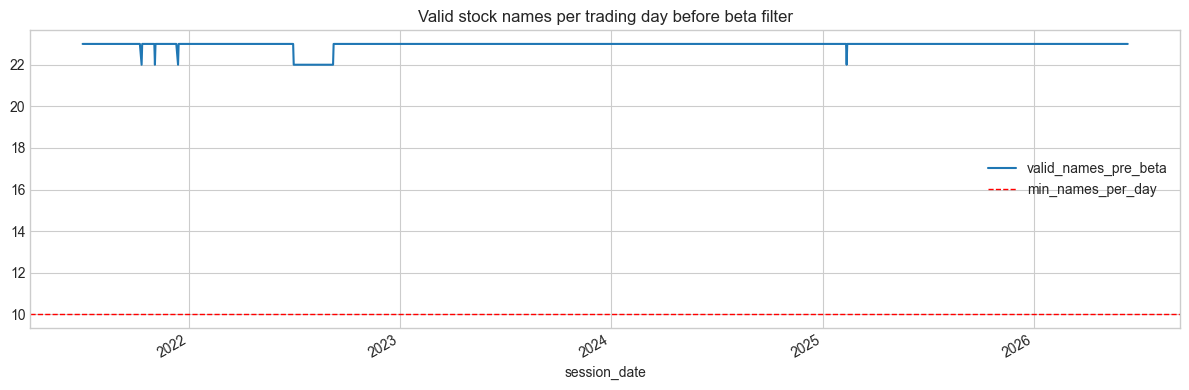

In [63]:
def required_bar_missing_report(features: pd.DataFrame) -> pd.DataFrame:
    if features.empty:
        return pd.DataFrame({"ticker": REQUESTED_TICKERS, "missing_required_days": np.nan, "complete_days": 0})
    cols = ["has_0930_bar", "has_signal_bar", "has_entry_window", "has_exit_window", "complete_required_bars"]
    report = features.groupby("ticker")[cols].sum().astype(int)
    report["total_days_seen"] = features.groupby("ticker")["session_date"].nunique().astype(int)
    for col in cols:
        report[f"missing_{col}"] = report["total_days_seen"] - report[col]
    return report.reset_index().sort_values("complete_required_bars", ascending=False)

missing_required = required_bar_missing_report(daily_features)
display(missing_required)
valid_names_by_day_pre_beta = daily_features[(daily_features["ticker"].isin(STOCK_TICKERS)) & daily_features["complete_required_bars"]].groupby("session_date")["ticker"].nunique().rename("valid_names_pre_beta") if not daily_features.empty else pd.Series(dtype=float, name="valid_names_pre_beta")
if not valid_names_by_day_pre_beta.empty:
    ax = valid_names_by_day_pre_beta.plot(figsize=(12, 4), title="Valid stock names per trading day before beta filter")
    ax.axhline(CONFIG["min_names_per_day"], color="red", linestyle="--", linewidth=1, label="min_names_per_day")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("information missing: no valid names by day because no complete required bars were loaded")

### Ticker Exclusion Summary

This table separates configured zero-bar exclusions from symbols that have some data but not enough complete required days to support the rolling beta lookback and first-pass signal test.

In [64]:
minimum_complete_days_for_research = CONFIG["beta_lookback_days"] + CONFIG["min_beta_obs"]
if missing_required.empty:
    ticker_exclusion_summary = pd.DataFrame(columns=["ticker", "bars", "complete_required_bars", "exclusion_reason"])
else:
    ticker_exclusion_summary = missing_required.merge(coverage[["ticker", "bars", "coverage_proxy"]], on="ticker", how="left")
    ticker_exclusion_summary["exclusion_reason"] = ""
    ticker_exclusion_summary.loc[ticker_exclusion_summary["bars"].fillna(0).eq(0), "exclusion_reason"] = "zero bars"
    some_data = ticker_exclusion_summary["bars"].fillna(0).gt(0)
    too_few_complete = ticker_exclusion_summary["complete_required_bars"].fillna(0).lt(minimum_complete_days_for_research)
    ticker_exclusion_summary.loc[some_data & too_few_complete, "exclusion_reason"] = "insufficient complete required days for rolling beta"
    ticker_exclusion_summary = ticker_exclusion_summary[ticker_exclusion_summary["exclusion_reason"].ne("")]
display(ticker_exclusion_summary.sort_values(["exclusion_reason", "ticker"]))

,ticker,has_0930_bar,has_signal_bar,has_entry_window,has_exit_window,complete_required_bars,total_days_seen,missing_has_0930_bar,missing_has_signal_bar,missing_has_entry_window,missing_has_exit_window,missing_complete_required_bars,bars,coverage_proxy,exclusion_reason


In [65]:
complete_features = daily_features[daily_features["complete_required_bars"]].copy() if not daily_features.empty else pd.DataFrame()
open_return_matrix = complete_features.pivot(index="session_date", columns="ticker", values="raw_open_return").sort_index() if not complete_features.empty else pd.DataFrame()
forward_return_matrix = complete_features.pivot(index="session_date", columns="ticker", values="forward_return").sort_index() if not complete_features.empty else pd.DataFrame()
benchmark = CONFIG["benchmark"]
if benchmark not in open_return_matrix.columns:
    print(f"information missing: benchmark {benchmark} has no complete required bars")
stock_columns = [c for c in STOCK_TICKERS if c in open_return_matrix.columns]
print("Complete stock columns:", len(stock_columns), stock_columns)
print("Complete ETF columns:", [c for c in ETF_TICKERS if c in open_return_matrix.columns])

Complete stock columns: 23 ['ACLS', 'ADI', 'AEIS', 'AMAT', 'AMD', 'AVGO', 'COHR', 'CRUS', 'FORM', 'INTC', 'KLAC', 'LRCX', 'LSCC', 'MCHP', 'MPWR', 'MRVL', 'MU', 'NVDA', 'NXPI', 'ON', 'QCOM', 'QRVO', 'STX']
Complete ETF columns: ['SMH', 'SOXX']


## 7. Beta Estimation

`beta_i,t = Cov(r_i, r_etf) / Var(r_etf)` using only dates `< t`.

Future versions may estimate beta using full-day returns, intraday returns, or robust regression, but this first notebook keeps it simple.

In [66]:
def estimate_prior_rolling_beta(open_rets: pd.DataFrame, benchmark_symbol: str, lookback: int, min_obs: int) -> pd.DataFrame:
    if benchmark_symbol not in open_rets.columns:
        return pd.DataFrame(index=open_rets.index, columns=open_rets.columns, dtype=float)
    etf = open_rets[benchmark_symbol]
    betas = pd.DataFrame(index=open_rets.index, columns=open_rets.columns, dtype=float)
    etf_var = etf.rolling(lookback, min_periods=min_obs).var()
    for ticker in open_rets.columns:
        if ticker == benchmark_symbol:
            betas[ticker] = 1.0
            continue
        betas[ticker] = (open_rets[ticker].rolling(lookback, min_periods=min_obs).cov(etf) / etf_var).shift(1)
    return betas.replace([np.inf, -np.inf], np.nan)

betas = estimate_prior_rolling_beta(open_return_matrix, benchmark, CONFIG["beta_lookback_days"], CONFIG["min_beta_obs"])
display(betas.reindex(columns=stock_columns).tail())

ticker,ACLS,ADI,AEIS,AMAT,AMD,AVGO,COHR,CRUS,FORM,INTC,KLAC,LRCX,LSCC,MCHP,MPWR,MRVL,MU,NVDA,NXPI,ON,QCOM,QRVO,STX
session_date,,,,,,,,,,,,,,,,,,,,,,,
2026-06-08,0.921110,0.704230,0.763846,1.128415,1.072588,0.735137,1.860949,0.300466,2.068767,1.455084,1.266440,1.201269,0.906974,0.526877,0.857098,1.933088,1.787220,0.687979,0.585863,1.013770,1.450937,0.253649,1.465991
2026-06-09,0.882311,0.779001,0.801178,1.056777,0.934582,0.830495,1.795604,0.465043,2.113833,1.385706,1.179086,1.301432,0.908481,0.788272,0.980286,2.100418,1.607053,0.655806,0.698410,1.080320,1.394797,0.317898,1.550887
2026-06-10,0.879409,0.775873,0.804221,1.050053,0.939562,0.824913,1.775642,0.470564,2.123284,1.401079,1.170906,1.290384,0.900817,0.781666,0.971417,2.101567,1.621418,0.641598,0.706970,1.074402,1.388267,0.309954,1.527319
2026-06-11,1.005438,0.773868,0.888507,1.132689,0.913170,0.696737,1.892541,0.473984,2.180193,1.450082,1.281326,1.419312,0.951560,0.756664,0.980730,1.947702,1.595226,0.639965,0.695836,0.926419,1.327589,0.275109,1.470140
2026-06-12,0.735945,0.706855,1.165330,1.059873,0.972430,0.723683,1.916285,0.398728,1.740478,1.469734,1.318185,1.348349,0.841054,0.627427,0.981417,1.947323,1.442969,0.636514,0.686358,0.961360,1.336672,0.354684,1.323068


## 8. Signal Definition

`residual_i,t = stock_open_return_i,t - beta_i,t * etf_open_return_t`

Cross-sectional z-scores are computed per date. Long candidates are the most negative z-scores; short candidates are the most positive z-scores.

TODO: optional volatility-scaled signal, e.g. `residual_i,t / rolling_intraday_vol_i,t`.

In [67]:
def cross_sectional_zscore(df: pd.DataFrame) -> pd.DataFrame:
    mean = df.mean(axis=1, skipna=True)
    std = df.std(axis=1, ddof=0, skipna=True).replace(0, np.nan)
    return df.sub(mean, axis=0).div(std, axis=0)

if benchmark in open_return_matrix.columns:
    etf_open_return = open_return_matrix[benchmark]
    stock_open_returns = open_return_matrix.reindex(columns=stock_columns)
    stock_betas = betas.reindex(columns=stock_columns)
    residuals = stock_open_returns.sub(stock_betas.mul(etf_open_return, axis=0))
    zscores = cross_sectional_zscore(residuals)
else:
    etf_open_return = pd.Series(dtype=float); stock_open_returns = pd.DataFrame(); stock_betas = pd.DataFrame(); residuals = pd.DataFrame(); zscores = pd.DataFrame()
valid_signal_names_by_day = zscores.notna().sum(axis=1).rename("valid_signal_names")
display(pd.concat([valid_names_by_day_pre_beta, valid_signal_names_by_day], axis=1).tail(20))
display(zscores.tail())

,valid_names_pre_beta,valid_signal_names
session_date,,
2026-05-15,23,23
2026-05-18,23,23
2026-05-19,23,23
2026-05-20,23,23
2026-05-21,23,23
2026-05-22,23,23
2026-05-26,23,23
2026-05-27,23,23
2026-05-28,23,23


ticker,ACLS,ADI,AEIS,AMAT,AMD,AVGO,COHR,CRUS,FORM,INTC,KLAC,LRCX,LSCC,MCHP,MPWR,MRVL,MU,NVDA,NXPI,ON,QCOM,QRVO,STX
session_date,,,,,,,,,,,,,,,,,,,,,,,
2026-06-08,1.360868,-0.389663,-0.503845,2.000351,0.231260,-1.422872,0.186962,0.327404,-0.841623,-1.584355,2.259649,0.762120,0.134594,-1.019247,-1.102609,0.852053,0.716511,-0.825603,-0.867915,0.433014,0.094688,-0.126532,-0.675211
2026-06-09,3.533070,0.002754,0.469753,0.997770,-0.763711,-0.278234,-1.321849,-0.175917,0.565240,-0.303013,0.824892,0.915890,-0.831748,0.113285,0.067563,-1.585845,-0.511589,-0.312906,-0.181379,0.150309,-0.693172,0.197921,-0.879085
2026-06-10,1.849056,-0.009104,0.768660,1.259237,-0.718822,-1.726668,0.782650,0.111486,0.833505,0.084435,1.553448,1.655950,0.378465,-0.538538,-0.089817,-1.536510,-0.440972,-0.286469,-0.238538,-1.719624,-0.757480,-0.506455,-0.707896
2026-06-11,-0.881003,-0.780626,1.675090,0.445568,1.440713,0.774014,0.115647,-0.027554,-2.245857,0.888764,1.361464,0.175234,-0.508202,-0.578944,-0.116848,-1.619556,-1.048965,0.057604,0.491503,-0.741296,0.981534,1.096723,-0.955005
2026-06-12,0.437506,-0.622013,1.011756,-0.911326,0.980711,-1.288869,-1.521512,0.488407,0.210479,0.386826,1.148993,-1.058448,0.012586,-0.274780,-1.504256,0.399071,0.425427,-0.914504,-0.798618,-0.315040,1.148709,-0.118948,2.677842


## 9. Portfolio Construction

Equal-weight bottom/top quantile basket. Long leg targets +0.5 gross, short leg targets -0.5 gross, with `max_weight_per_name` respected first. Optional ETF hedge logic is included but disabled by default.

In [68]:
def select_tail_names(row: pd.Series, long_quantile: float, short_quantile: float) -> tuple[list[str], list[str]]:
    valid = row.dropna().sort_values(); n = len(valid)
    if n < CONFIG["min_names_per_day"]:
        return [], []
    return valid.head(max(1, int(math.ceil(n * long_quantile)))).index.tolist(), valid.tail(max(1, int(math.ceil(n * short_quantile)))).index.tolist()

def capped_equal_leg(names: list[str], sign: float, target_leg_gross: float, max_abs_weight: float) -> dict[str, float]:
    if not names:
        return {}
    feasible_leg_gross = min(target_leg_gross, len(names) * max_abs_weight)
    return {name: sign * min(feasible_leg_gross / len(names), max_abs_weight) for name in names}

def construct_daily_weights(z: pd.DataFrame, beta: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    weights = pd.DataFrame(0.0, index=z.index, columns=z.columns); diagnostics = []; target_leg_gross = CONFIG["gross_exposure"] / 2
    for dt, row in z.iterrows():
        longs, shorts = select_tail_names(row, CONFIG["long_quantile"], CONFIG["short_quantile"])
        if not longs or not shorts:
            diagnostics.append({"session_date": dt, "long_names": 0, "short_names": 0, "used": False, "skip_reason": "insufficient signal names"}); continue
        for ticker, weight in {**capped_equal_leg(longs, 1.0, target_leg_gross, CONFIG["max_weight_per_name"]), **capped_equal_leg(shorts, -1.0, target_leg_gross, CONFIG["max_weight_per_name"])}.items():
            weights.loc[dt, ticker] = weight
        diagnostics.append({"session_date": dt, "long_names": int((weights.loc[dt] > 0).sum()), "short_names": int((weights.loc[dt] < 0).sum()), "gross_exposure": weights.loc[dt].abs().sum(), "net_exposure": weights.loc[dt].sum(), "beta_exposure": (weights.loc[dt] * beta.reindex(index=[dt], columns=z.columns).iloc[0]).sum(skipna=True), "used": weights.loc[dt].abs().sum() > 0, "skip_reason": ""})
    return weights, pd.DataFrame(diagnostics).set_index("session_date") if diagnostics else pd.DataFrame()

stock_weights, weight_diagnostics = construct_daily_weights(zscores, stock_betas)
if CONFIG["use_etf_hedge"] and benchmark in open_return_matrix.columns:
    weights = stock_weights.copy(); weights[benchmark] = -(stock_weights * stock_betas).sum(axis=1)
else:
    weights = stock_weights.copy()
used_days = weights.abs().sum(axis=1).gt(0) if not weights.empty else pd.Series(dtype=bool)
display(weight_diagnostics.tail(20))
print("Trading days with non-zero weights:", int(used_days.sum()))

,long_names,short_names,used,skip_reason,gross_exposure,net_exposure,beta_exposure
session_date,,,,,,,
2026-05-15,5,5,True,,0.5,0.000000e+00,-0.194294
2026-05-18,5,5,True,,0.5,-1.387779e-17,-0.178591
2026-05-19,5,5,True,,0.5,0.000000e+00,0.215961
2026-05-20,5,5,True,,0.5,-1.387779e-17,0.196947
2026-05-21,5,5,True,,0.5,0.000000e+00,-0.067746
2026-05-22,5,5,True,,0.5,1.387779e-17,0.245271
2026-05-26,5,5,True,,0.5,1.387779e-17,0.123970
2026-05-27,5,5,True,,0.5,0.000000e+00,-0.308887
2026-05-28,5,5,True,,0.5,1.387779e-17,0.033546


Trading days with non-zero weights: 1223


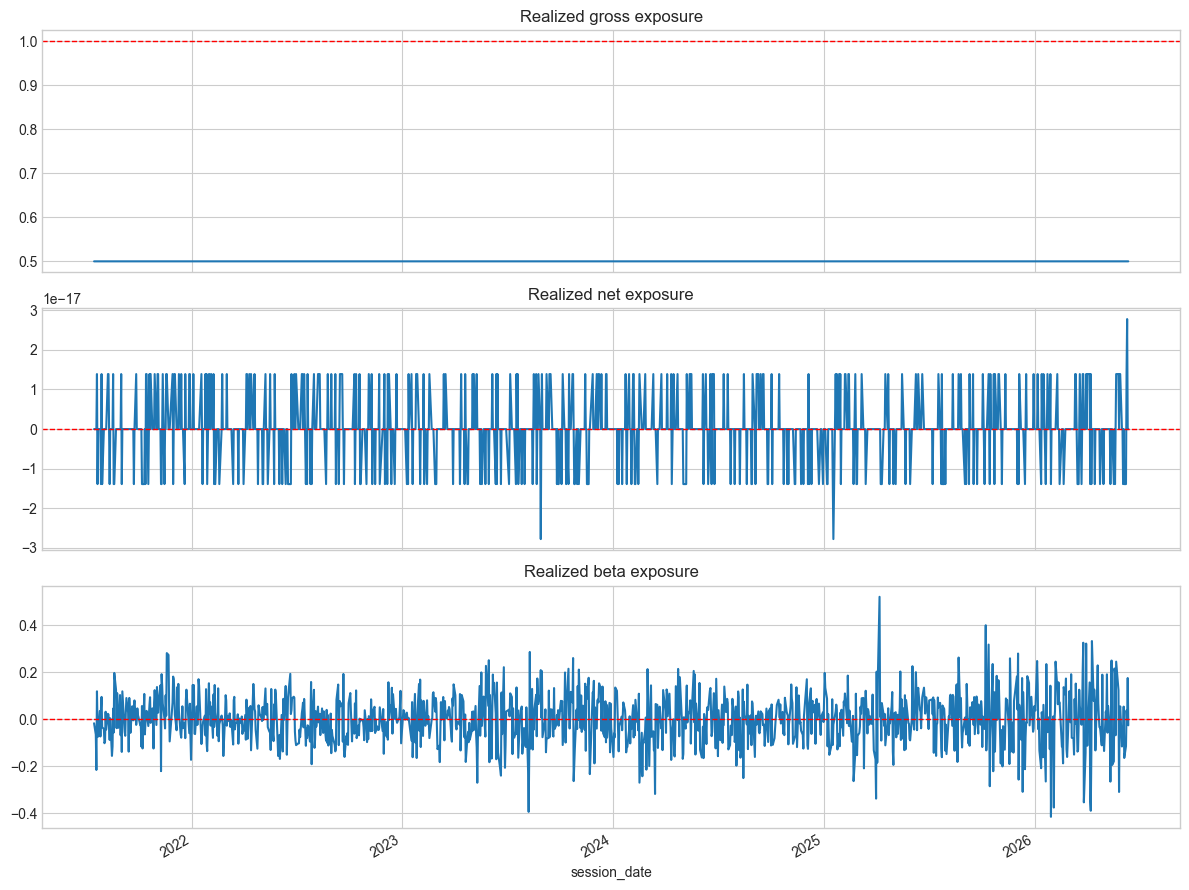

In [69]:
if not weight_diagnostics.empty and "gross_exposure" in weight_diagnostics.columns:
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    weight_diagnostics["gross_exposure"].plot(ax=axes[0], title="Realized gross exposure")
    weight_diagnostics["net_exposure"].plot(ax=axes[1], title="Realized net exposure")
    weight_diagnostics["beta_exposure"].plot(ax=axes[2], title="Realized beta exposure")
    axes[0].axhline(CONFIG["gross_exposure"], color="red", linestyle="--", linewidth=1)
    axes[1].axhline(CONFIG["target_net_exposure"], color="red", linestyle="--", linewidth=1)
    axes[2].axhline(CONFIG["target_beta_exposure"], color="red", linestyle="--", linewidth=1)
    plt.tight_layout(); plt.show()

## 10. PnL Calculation and Metrics

For each date/ticker, `forward_return_i,t = exit_price_i,t / entry_price_i,t - 1` and `gross_pnl_i,t = weight_i,t * forward_return_i,t`.

For each cost assumption, round-trip cost is `2 * cost_bps_per_side / 10000 * abs(weight_i,t)`. The notebook assumes a full daily rebalance from cash because there is no overnight exposure.

In [70]:
def calculate_pnl_by_cost(weights: pd.DataFrame, forward_returns: pd.DataFrame, betas_for_weights: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, pd.DataFrame]]:
    common_idx = weights.index.intersection(forward_returns.index); common_cols = weights.columns.intersection(forward_returns.columns)
    w = weights.loc[common_idx, common_cols].fillna(0.0); r = forward_returns.loc[common_idx, common_cols]
    per_name_pnl = w * r; daily = pd.DataFrame(index=common_idx)
    daily["gross_pnl"] = per_name_pnl.sum(axis=1, skipna=True); daily["long_leg_pnl"] = per_name_pnl.where(w > 0).sum(axis=1, skipna=True); daily["short_leg_pnl"] = per_name_pnl.where(w < 0).sum(axis=1, skipna=True)
    daily["gross_exposure"] = w.abs().sum(axis=1); daily["net_exposure"] = w.sum(axis=1); daily["long_names"] = (w > 0).sum(axis=1); daily["short_names"] = (w < 0).sum(axis=1); daily["names"] = (w != 0).sum(axis=1); daily["turnover_proxy"] = daily["gross_exposure"] * 2.0
    daily["beta_exposure"] = (w * betas_for_weights.reindex(index=common_idx, columns=common_cols)).sum(axis=1, skipna=True)
    by_cost = {}
    for bps in CONFIG["cost_bps_per_side_grid"]:
        pnl = daily.copy(); pnl["cost_bps_per_side"] = bps; pnl["costs"] = ((2 * bps / 10_000.0) * w.abs()).sum(axis=1); pnl["net_pnl"] = pnl["gross_pnl"] - pnl["costs"]; by_cost[bps] = pnl
    return daily, per_name_pnl, by_cost

def max_drawdown_from_returns(returns: pd.Series) -> float:
    returns = returns.dropna()
    if returns.empty: return np.nan
    equity = (1 + returns).cumprod(); return float((equity / equity.cummax() - 1).min())

def annualized_return(returns: pd.Series, periods_per_year: int = 252) -> float:
    returns = returns.dropna()
    if returns.empty: return np.nan
    compounded = float((1 + returns).prod()); years = len(returns) / periods_per_year
    return compounded ** (1 / years) - 1 if years > 0 and compounded > 0 else np.nan

def summarize_strategy(pnl: pd.DataFrame, cost_bps: int) -> pd.Series:
    active = pnl[pnl["gross_exposure"].gt(0)].copy(); gross = active["gross_pnl"].dropna(); net = active["net_pnl"].dropna(); net_vol = net.std(ddof=1); gross_vol = gross.std(ddof=1)
    return pd.Series({"cost_bps_per_side": cost_bps, "number_of_trading_days_used": int(len(active)), "average_number_of_names_per_day": active["names"].mean(), "average_long_names": active["long_names"].mean(), "average_short_names": active["short_names"].mean(), "average_gross_exposure": active["gross_exposure"].mean(), "average_net_exposure": active["net_exposure"].mean(), "average_beta_exposure": active["beta_exposure"].mean(), "cumulative_gross_return": (1 + gross).prod() - 1 if len(gross) else np.nan, "cumulative_net_return": (1 + net).prod() - 1 if len(net) else np.nan, "annualized_gross_return": annualized_return(gross), "annualized_net_return": annualized_return(net), "annualized_net_volatility": net_vol * np.sqrt(252) if pd.notna(net_vol) else np.nan, "gross_sharpe_ratio": gross.mean() / gross_vol * np.sqrt(252) if gross_vol and pd.notna(gross_vol) else np.nan, "net_sharpe_ratio": net.mean() / net_vol * np.sqrt(252) if net_vol and pd.notna(net_vol) else np.nan, "hit_ratio": (net > 0).mean() if len(net) else np.nan, "max_drawdown": max_drawdown_from_returns(net), "average_daily_pnl": net.mean(), "median_daily_pnl": net.median(), "best_day": net.max() if len(net) else np.nan, "worst_day": net.min() if len(net) else np.nan, "long_leg_pnl": active["long_leg_pnl"].sum(), "short_leg_pnl": active["short_leg_pnl"].sum(), "average_daily_cost": active["costs"].mean(), "turnover_proxy": active["turnover_proxy"].mean()})

beta_for_weights = stock_betas.copy()
if CONFIG["use_etf_hedge"] and benchmark in weights.columns: beta_for_weights[benchmark] = 1.0
daily_gross, per_name_pnl, pnl_by_cost = calculate_pnl_by_cost(weights, forward_return_matrix, beta_for_weights)
metrics = pd.DataFrame([summarize_strategy(pnl, bps) for bps, pnl in pnl_by_cost.items()])
display(metrics)

,cost_bps_per_side,number_of_trading_days_used,average_number_of_names_per_day,average_long_names,average_short_names,average_gross_exposure,average_net_exposure,average_beta_exposure,cumulative_gross_return,cumulative_net_return,annualized_gross_return,annualized_net_return,annualized_net_volatility,gross_sharpe_ratio,net_sharpe_ratio,hit_ratio,max_drawdown,average_daily_pnl,median_daily_pnl,best_day,worst_day,long_leg_pnl,short_leg_pnl,average_daily_cost,turnover_proxy
0,1.0,1223.0,10.0,5.0,5.0,0.5,1.702100e-19,-0.000211,0.101841,-0.024997,0.020184,-0.005203,0.036268,0.569129,-0.125698,0.502044,-0.147041,-0.000018,0.000011,0.008365,-0.007439,0.14991,-0.049735,0.0001,1.0
1,2.0,1223.0,10.0,5.0,5.0,0.5,1.702100e-19,-0.000211,0.101841,-0.137244,0.020184,-0.029960,0.036268,0.569129,-0.820526,0.484873,-0.192935,-0.000118,-0.000089,0.008265,-0.007539,0.14991,-0.049735,0.0002,1.0
2,5.0,1223.0,10.0,5.0,5.0,0.5,1.702100e-19,-0.000211,0.101841,-0.402275,0.020184,-0.100610,0.036268,0.569129,-2.905007,0.421913,-0.413134,-0.000418,-0.000389,0.007965,-0.007839,0.14991,-0.049735,0.0005,1.0
3,10.0,1223.0,10.0,5.0,5.0,0.5,1.702100e-19,-0.000211,0.101841,-0.675846,0.020184,-0.207152,0.036268,0.569129,-6.379144,0.331153,-0.678936,-0.000918,-0.000889,0.007465,-0.008339,0.14991,-0.049735,0.0010,1.0


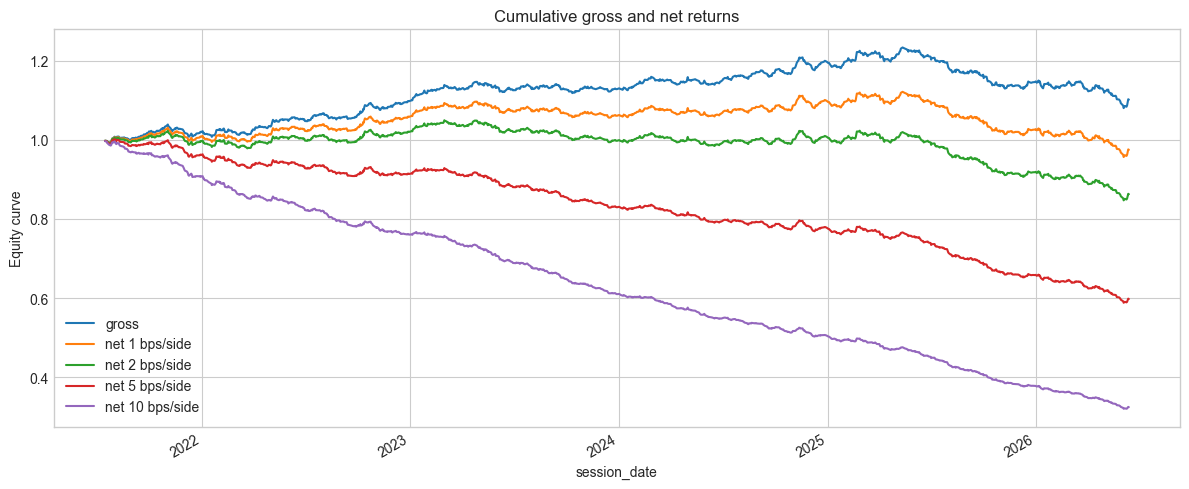

,cost_bps_per_side,cumulative_net_return,annualized_net_return,net_sharpe_ratio,average_daily_cost
0,1.0,-0.024997,-0.005203,-0.125698,0.0001
1,2.0,-0.137244,-0.029960,-0.820526,0.0002
2,5.0,-0.402275,-0.100610,-2.905007,0.0005
3,10.0,-0.675846,-0.207152,-6.379144,0.0010


In [77]:
if pnl_by_cost:
    fig, ax = plt.subplots(figsize=(12, 5)); gross_active = daily_gross[daily_gross["gross_exposure"].gt(0)]["gross_pnl"]
    if not gross_active.empty: (1 + gross_active).cumprod().plot(ax=ax, label="gross")
    for bps, pnl in pnl_by_cost.items():
        active_net = pnl[pnl["gross_exposure"].gt(0)]["net_pnl"]
        if not active_net.empty: (1 + active_net).cumprod().plot(ax=ax, label=f"net {bps} bps/side")
    ax.set_title("Cumulative gross and net returns"); ax.set_ylabel("Equity curve"); ax.legend(); plt.tight_layout(); plt.show()
    cost_sensitivity = metrics[["cost_bps_per_side", "cumulative_net_return", "annualized_net_return", "net_sharpe_ratio", "average_daily_cost"]]
    display(cost_sensitivity)
else:
    cost_sensitivity = pd.DataFrame()

## 11. Diagnostics

Check best/worst days, long-leg versus short-leg contribution, cost sensitivity, turnover proxy, and ticker-level contribution before drawing conclusions.

,gross_pnl,long_leg_pnl,short_leg_pnl,gross_exposure,net_exposure,long_names,short_names,names,turnover_proxy,beta_exposure,cost_bps_per_side,costs,net_pnl
session_date,,,,,,,,,,,,,
2025-10-01,-0.007339,0.006087,-0.013426,0.5,0.000000e+00,5,5,10,1.0,0.043956,1,0.0001,-0.007439
2025-04-03,-0.007335,-0.013977,0.006642,0.5,0.000000e+00,5,5,10,1.0,-0.184288,1,0.0001,-0.007435
2026-04-22,-0.006109,-0.000338,-0.005771,0.5,0.000000e+00,5,5,10,1.0,0.011964,1,0.0001,-0.006209
2025-07-01,-0.006096,-0.001681,-0.004415,0.5,1.387779e-17,5,5,10,1.0,-0.041200,1,0.0001,-0.006196
2023-05-01,-0.006055,-0.001359,-0.004696,0.5,0.000000e+00,5,5,10,1.0,-0.052884,1,0.0001,-0.006155
2026-06-03,-0.005999,0.001095,-0.007094,0.5,0.000000e+00,5,5,10,1.0,-0.072127,1,0.0001,-0.006099
2026-03-24,-0.005980,0.002898,-0.008878,0.5,0.000000e+00,5,5,10,1.0,0.032873,1,0.0001,-0.006080
2026-05-08,-0.005741,-0.001404,-0.004336,0.5,0.000000e+00,5,5,10,1.0,0.056411,1,0.0001,-0.005841
2023-05-31,-0.005581,-0.003771,-0.001810,0.5,-1.387779e-17,5,5,10,1.0,0.251207,1,0.0001,-0.005681


,gross_pnl,long_leg_pnl,short_leg_pnl,gross_exposure,net_exposure,long_names,short_names,names,turnover_proxy,beta_exposure,cost_bps_per_side,costs,net_pnl
session_date,,,,,,,,,,,,,
2025-02-20,0.008465,0.005912,0.002553,0.5,0.000000e+00,5,5,10,1.0,0.014647,1,0.0001,0.008365
2026-06-10,0.007191,-0.006303,0.013494,0.5,-1.387779e-17,5,5,10,1.0,-0.009266,1,0.0001,0.007091
2026-06-11,0.007030,0.012681,-0.005651,0.5,0.000000e+00,5,5,10,1.0,0.175650,1,0.0001,0.006930
2025-02-21,0.006837,-0.003219,0.010056,0.5,-1.387779e-17,5,5,10,1.0,-0.262753,1,0.0001,0.006737
2025-01-27,0.006746,-0.005158,0.011905,0.5,0.000000e+00,5,5,10,1.0,-0.061053,1,0.0001,0.006646
2022-10-13,0.006420,0.019749,-0.013329,0.5,0.000000e+00,5,5,10,1.0,0.122909,1,0.0001,0.006320
2022-01-27,0.006305,-0.006686,0.012990,0.5,1.387779e-17,5,5,10,1.0,-0.102242,1,0.0001,0.006205
2026-01-14,0.005757,0.002352,0.003405,0.5,0.000000e+00,5,5,10,1.0,0.009320,1,0.0001,0.005657
2022-10-11,0.005739,0.001699,0.004041,0.5,-1.387779e-17,5,5,10,1.0,0.067647,1,0.0001,0.005639


,gross_pnl_contribution
ticker,
AMD,-0.076241
MRVL,-0.029276
AVGO,-0.027991
INTC,-0.025100
FORM,-0.015261
QCOM,-0.012880
ON,-0.010358
KLAC,-0.002521
NVDA,-0.001719


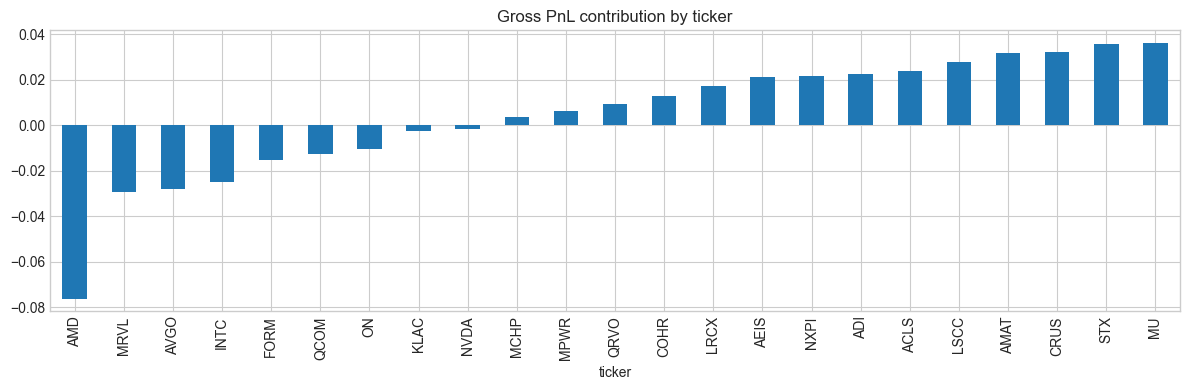

In [71]:
if pnl_by_cost:
    base_bps = CONFIG["cost_bps_per_side_grid"][0]
    diagnostic_pnl = pnl_by_cost[base_bps][pnl_by_cost[base_bps]["gross_exposure"].gt(0)].copy()
    display(diagnostic_pnl.sort_values("net_pnl").head(10))
    display(diagnostic_pnl.sort_values("net_pnl", ascending=False).head(10))
    if not per_name_pnl.empty:
        contribution = per_name_pnl.sum().sort_values()
        display(contribution.to_frame("gross_pnl_contribution"))
        contribution.plot.bar(figsize=(12, 4), title="Gross PnL contribution by ticker")
        plt.tight_layout(); plt.show()

## 12. Optional Output Save

By default `CONFIG["save_outputs"]` is `False` to keep this first research notebook exploratory. Turn it on after reviewing data quality.

Outputs: `signals.csv`, `positions.csv`, `trades.csv`, `daily_pnl.csv`, `metrics.csv`, `cost_sensitivity.csv`, `research_memo.md`.

In [78]:
if CONFIG["save_outputs"]:
    signals = zscores.stack().rename("zscore").reset_index().rename(columns={"level_1": "ticker"})
    residual_out = residuals.stack().rename("residual").reset_index().rename(columns={"level_1": "ticker"})
    signals = signals.merge(residual_out, on=["session_date", "ticker"], how="left")
    signals.to_csv(OUTPUT_DIR / "signals.csv", index=False)
    positions = weights.stack().rename("weight").reset_index().rename(columns={"level_1": "ticker"})
    positions = positions[positions["weight"].ne(0)]
    positions.to_csv(OUTPUT_DIR / "positions.csv", index=False)
    trades = positions.merge(complete_features[["session_date", "ticker", "entry_price", "exit_price", "forward_return", "entry_volume", "exit_volume"]], on=["session_date", "ticker"], how="left")
    trades.to_csv(OUTPUT_DIR / "trades.csv", index=False)
    daily_panel = pd.concat(pnl_by_cost.values(), axis=0).reset_index().rename(columns={"index": "session_date"})
    daily_panel.to_csv(OUTPUT_DIR / "daily_pnl.csv", index=False)
    metrics.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
    cost_sensitivity.to_csv(OUTPUT_DIR / "cost_sensitivity.csv", index=False)
    memo = chr(10).join(["# Basket StatArb Research Memo", "", "Decision: revise", "", "Research-only vector notebook output. Review data quality, costs, leg attribution, beta exposure, and missing inputs before any further simulator work.", ""])
    (OUTPUT_DIR / "research_memo.md").write_text(memo, encoding="utf-8")
    print("Saved outputs to", OUTPUT_DIR)
else:
    print("Output saving disabled. Set CONFIG['save_outputs'] = True after reviewing data quality.")

Saved outputs to /Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey/research/Jordi/cross_sectional_equity_dispersion/outputs/01_vector_research_semis


In [80]:
#CONFIG["save_outputs"]=True
OUTPUT_DIR

PosixPath('/Users/marina/Documents/jordi/projects/Trading/bluegrey/1.Cloud/Bluegrey/research/Jordi/cross_sectional_equity_dispersion/outputs/01_vector_research_semis')

## 13. Research Decision

Allowed decisions:
- `reject`
- `revise`
- `expand`
- `paper observation candidate`

Not allowed:
- `approved for live trading`

Initial default decision for this first vector notebook: `revise` until data coverage, corporate actions, earnings, borrow, costs, and robustness diagnostics are reviewed.